# Eigenmode

In [1]:
import sys
sys.path.append("../..")
import numpy as np
import json
import matplotlib
import matplotlib.pyplot as plt
import time
plt.ion()
%matplotlib inline
from cavsim2d.cavity import Cavity, Cavities, OperationPoints, EllipticalCavity
import pprint
pp = pprint.PrettyPrinter(indent=4)

In [2]:
%%time
from cavsim2d.cavity import *
# create cavities
cavs = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations')
# must first save cavities

# define geometry parameters
# midcell = np.array([42, 42, 12, 19, 35, 57.7, 103.353])
# endcell_l = np.array([40.34, 40.34, 10, 13.5, 39, 55.716, 103.353])
# endcell_r = np.array([42, 42, 9, 12.8, 39, 56.815, 103.353])
midcell = [62.22, 66.13, 30.22, 23.11, 80, 93.5, 171.20]  # <- A, B, a, b, Ri, L, Req
endcell_l = [62.58, 57.54, 17.21, 12, 80, 93.795, 171.20]
endcell_r = [62.58, 57.54, 17.21, 12, 80, 93.795, 171.20]
# create cavity
cav1 = EllipticalCavity(2, midcell, endcell_l, endcell_r, beampipe='both')
cavs.add_cavity([cav1], ['C3795'])

eigenmode_config = {
    'processes': 1,
    'rerun': True,
    'boundary_conditions': 'mm'
    }
# run eigenmode analysis
cavs.run_eigenmode(eigenmode_config)  #modify to delete UQ results if rerun=True is selected

CPU times: total: 2.25 s
Wall time: 2.17 s


In [3]:
cav1.plot_fields(1, 'E', 'quadrupole')

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

In [4]:
pp.pprint(cavs.eigenmode_qois)

{   'C3795': {   'Bpk [mT]': 6.374613742616638e-05,
                 'Bpk/Eacc [mT/MV/m]': 5.085678431117474,
                 'Eacc [MV/m]': 1.2534441233273072e-05,
                 'Epk [MV/m]': 3.073020339065295e-05,
                 'Epk/Eacc []': 2.4516612123944266,
                 'G [Ohm]': 443.3947761186126,
                 'GR/Q [Ohm^2]': 68758.24344291865,
                 'Hpk [A/m]': 0.050727564371948246,
                 'N Cells': 2,
                 'No of Mesh Elements': 209,
                 'Normalization Length [mm]': 187.0,
                 'Q []': 60501.14434326378,
                 'R/Q [Ohm]': 155.07229030710351,
                 'Rsh [MOhm]': 9.382051019510575,
                 'Vacc [MV]': 4.6878810212441286e-06,
                 'ff [%]': 99.95665039137104,
                 'freq [MHz]': 810.8499401777361,
                 'kcc [%]': 2.236879797366646}}


{'Epk/Eacc []': <Axes: label='Epk/Eacc []', ylabel='$E_\\mathrm{pk}/E_\\mathrm{acc} ~[\\cdot]$'>,
 'Bpk/Eacc [mT/MV/m]': <Axes: label='Bpk/Eacc [mT/MV/m]', ylabel='$B_\\mathrm{pk}/E_\\mathrm{acc} ~\\mathrm{[mT/MV/m]}$'>,
 'kcc [%]': <Axes: label='kcc [%]', ylabel='$k_\\mathrm{cc}$ [%]'>,
 'R/Q [Ohm]': <Axes: label='R/Q [Ohm]', ylabel='$R/Q ~\\mathrm{[\\Omega]}$'>,
 'G [Ohm]': <Axes: label='G [Ohm]', ylabel='$G ~\\mathrm{[\\Omega]}$'>,
 'GR/Q [Ohm^2]': <Axes: label='GR/Q [Ohm^2]', ylabel='$G \\cdot R/Q \\mathrm{[\\Omega^2]}$'>}

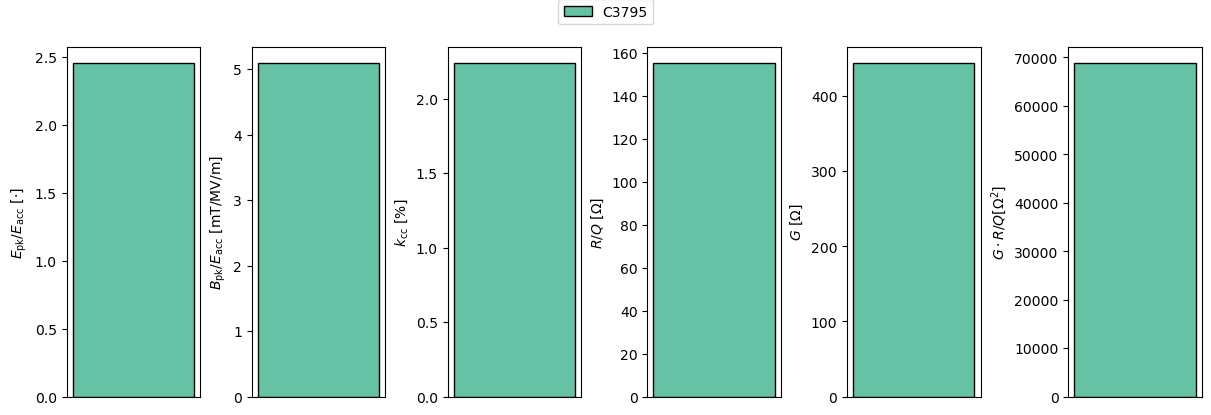

In [5]:
cavs.plot_compare_fm_bar()

# m-pole eigenmodes (dipole, quadrupole, sextupole, ...)

Higher-order azimuthal modes ($m \geq 1$) are solved on the same 2D meridian domain using the Fourier ansatz
$\mathbf{E} = (E_r, E_z)\cos(m\varphi) + E_\varphi \sin(m\varphi)\,\hat{e}_\varphi$
with the scaled azimuthal unknown $\tilde{u}_\varphi = r E_\varphi$, discretised on the product space $H(\mathrm{curl}) \times H^1$. The gradient kernel $(\mathbf{u}, \tilde{u}_\varphi) = (-\nabla\psi, m\psi)$ is projected out of the PINVIT iteration (analogous to the monopole gradient projection), so only the requested number of physical modes is computed.

**Usage** — add `'polarisation'` to `eigenmode_config` (names or azimuthal mode numbers, single value or list). Every polarisation gets its own subfolder:

- monopole → `<cavity>/eigenmode/monopole/`
- dipole → `<cavity>/eigenmode/dipole/`, quadrupole → `eigenmode/quadrupole/`, sextupole → `eigenmode/sextupole/`, ...

each with `qois.json`, `qois_all_modes.json`, `mesh.pkl`, `gfu_EH.pkl` and (for $m \geq 1$) off-axis field profiles `Ez_r0_abs_mode_<i>.csv`. With `rerun=True` only the polarisations listed in the config are cleared and re-solved — a dipole rerun never overwrites existing monopole results, and vice versa. With `rerun=False` only missing polarisations are solved.

**QOI conventions for $m \geq 1$** — since $E_z \sim r^m$ vanishes on axis, the longitudinal voltage is integrated along the off-axis line $r_0 = \tfrac{1}{2} r_\mathrm{aperture}$ and converted to the transverse kick voltage via Panofsky–Wenzel, $V_t = m V_z(r_0)/(k r_0)$. The keys `Vacc`/`Eacc`/`R/Q` hold these transverse analogues; `R/Q_t [Ohm/m^(2(m-1))]` is additionally normalised by $r_0^{2(m-1)}$ so it is independent of the choice of $r_0$ (identical to `R/Q [Ohm]` for the dipole). Peak surface fields are exact azimuthal maxima, $\max(|\mathbf{E}_{rz}|, |E_\varphi|)$.

In [6]:
%%time
eigenmode_config = {
    'processes': 1,
    'rerun': True,
    'boundary_conditions': 'mm',
    'polarisation': ['monopole', 'dipole', 'quadrupole'],  # names or m numbers, e.g. [0, 1, 2]
    'n_modes': 4,  # physical modes per m-pole solve (monopole mode count is unchanged)
    }
# run eigenmode analysis for all requested polarisations on one mesh
cavs.run_eigenmode(eigenmode_config)

CPU times: total: 9.38 s
Wall time: 5.56 s


In [7]:
# QOIs of all computed dipole modes (same access pattern for 'quadrupole', 'sextupole', ...)
# pp.pprint(cav1.eigenmode.mpole_qois('dipole'))

In [8]:
# mode summary as EigenmodeResult objects (index, frequency, azimuthal mode number m)
for mode in cav1.eigenmode.mpole_modes('dipole'):
    print(mode)
for mode in cav1.eigenmode.mpole_modes('quadrupole'):
    print(mode)

EigenmodeResult(index=0, f=891.18 MHz, m=1)
EigenmodeResult(index=1, f=981.53 MHz, m=1)
EigenmodeResult(index=2, f=1050.67 MHz, m=1)
EigenmodeResult(index=3, f=1115.55 MHz, m=1)
EigenmodeResult(index=0, f=1354.68 MHz, m=2)
EigenmodeResult(index=1, f=1385.75 MHz, m=2)
EigenmodeResult(index=2, f=1457.00 MHz, m=2)
EigenmodeResult(index=3, f=1485.61 MHz, m=2)


In [9]:
# in-plane |E| envelope of the first dipole mode.
# which='Ephi' / 'H' / 'Hphi' select the azimuthal E and the H envelopes.
cav1.plot_fields(mode=0, which='E', pol='dipole')

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

# Eigenmode + UQ

In [10]:
from cavsim2d.cavity import *
# create cavities
cavs = Cavities()
# must first save cavities
cavs.save('D:\Dropbox\CavityDesignHub\MuCol_Study\SimulationData\ConsoleTest')

# define geometry parameters
midcell = np.array([42, 42, 12, 19, 35, 57.7, 103.353])
endcell_l = np.array([40.34, 40.34, 10, 13.5, 39, 55.716, 103.353])
endcell_r = np.array([42, 42, 9, 12.8, 39, 56.815, 103.353])
# create cavity
cav1 = EllipticalCavity(2, midcell, endcell_l, endcell_r, beampipe='both')
cavs.add_cavity([cav1], ['TESLA'])

eigenmode_config = {
    'processes': 3,
    'rerun': True,
    'boundary_conditions': 'mm',
    'uq_config': {
        'variables': ['A', 'B', 'a', 'b'],
        'objectives': ["Epk/Eacc []", "Bpk/Eacc [mT/MV/m]", "R/Q [Ohm]", "G [Ohm]"],
        'delta': [0.05, 0.05, 0.05, 0.05],
        'processes': 4,
        'distribution': 'gaussian',
        'method': ['Quadrature', 'Stroud3'],
        'cell_type': 'mid-cell',
        'cell complexity': 'multicell'
        }
    }
# run eigenmode analysis
cavs.run_eigenmode(eigenmode_config)  #modify to delete UQ results if rerun=True is selected

<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Soske\AppData\Local\Temp\ipykernel_44008\1925552042.py:5: SyntaxWarning: invalid escape sequence '\D'
  cavs.save('D:\Dropbox\CavityDesignHub\MuCol_Study\SimulationData\ConsoleTest')
C:\Users\Soske\AppData\Local\Temp\ipykernel_44008\1925552042.py:5: SyntaxWarning: invalid escape sequence '\D'
  cavs.save('D:\Dropbox\CavityDesignHub\MuCol_Study\SimulationData\ConsoleTest')


TypeError: Cavities.__init__() missing 1 required positional argument: 'folder'

In [ ]:
pp.pprint(cavs.uq_fm_results)

In [ ]:
cavs.plot_compare_fm_scatter(uq=True)

In [ ]:
# cavs.plot_uq_geometries()